# **Un modelos básico de clasificación: KNN**

El objetivo de este libro de notas es presentar la técnica de K vecinos más cercanos como alternativa al problema de clasificación.

In [72]:
if (!require('readxl')) install.packages('readxl')
if (!require('caret')) install.packages('caret')
if (!require('MLmetrics')) install.packages('MLmetrics')
if (!require('e1071')) install.packages('e1071')

## **KNN**

#Data and business understanding

In [73]:
library(readxl)
library(caret)
library(MLmetrics)
library(ROCR)
library(e1071)

Trabajaremos con el contexto del archivo de cartera de empresas. Para mantener los libros de nota modulares, repetiré aquí el contexto:

In [74]:
cartera<-read_excel("carteraguia2017.xlsx")

In [75]:
str(cartera)

tibble [852 × 9] (S3: tbl_df/tbl/data.frame)
 $ MESES                   : num [1:852] 41 27 40 41 24 41 39 43 24 36 ...
 $ TIPO_ips                : num [1:852] 3 1 1 1 2 2 1 1 1 1 ...
 $ IGUAL_DUENO             : num [1:852] 17 10 15 15 2 5 20 12 3 0 ...
 $ AGNOS_DIRECCION_ACTUAL  : num [1:852] 12 6 14 14 0 5 9 11 4 13 ...
 $ VENTAS_MENS_PROMEDIO    : num [1:852] 176 31 55 120 28 25 67 38 19 25 ...
 $ PORC_PASIVOS_VENTA_ANUAL: num [1:852] 9.3 17.3 5.5 2.9 17.3 10.2 30.6 3.6 24.4 19.7 ...
 $ cartera_actual_insumos_A: num [1:852] 11.359 1.362 0.856 2.659 1.787 ...
 $ cartera_actual_insumos_B: num [1:852] 5.009 4.001 2.169 0.821 3.057 ...
 $ retrasos                : num [1:852] 1 0 0 0 1 0 0 0 1 0 ...


El archivo contiene datos de clientes de un proveedor de instituciones de salud (IPS), la cartera que presentan y si se han retrasado o no. Se trata entonces de un negocio B2B en el sector de la salud que desea predecir o averiguar indicadores de posibles aumentos y retrasos en su cartera

Entre las variables predictoras se incluyen:

MESES: Los meses que la empresa lleva siendo clientes del proveedor.

Tipo_IPS: De 1 a5, el nivel de complejidad de la institución de salud cliente (1=bajo, 5=alto)

IGUAL_DUEÑO: Número de años en que la IPS ha tenido el mismo dueño.

AGNOS_DIRECCION_ACTUAL: Número de años en que la IPS ha estado en la misma dirección.

VENTAS_MENS_PROMEDIO: Valor de ventas mensuales promedio de la IPS en millones de pesos.

PORC_PASIVOS_VENTA_ANUAL: Porcentaje de pasivos/ venta anual del último balance disponible.

CARTERA_ACTUAL_INSUMOS_A: Valor de la deuda con el proveedor en insumos de alta rotación (gasa, jeringas, por ejemplo) en millones de pesos.

CARTERA_ACTUAL_INSUMOS_B: Valor de la deuda con el proveedor en insumos de baja rotación (equipos, instrumentos, por ejemplo) en millones de pesos.

La variable a predecir son los RETRASOS, que indican sí el cliente se ha retrasado o no, siendo 1=sí y 0=No.

# Data preparation

Primero vamos a convertir a factores las dos variables que lo requieren: Tipo IPS y Retrasos y reordenamos la base de datos para dejar los predictores escalares juntos

In [76]:
cartera$TIPOips<-as.factor(cartera$TIPO_ips)
cartera$retrasos<-as.factor(cartera$retrasos)
carterafin2<-cartera[,c(1,3,4,5,6,7,8,2,9)]


In [77]:
str(carterafin2)

tibble [852 × 9] (S3: tbl_df/tbl/data.frame)
 $ MESES                   : num [1:852] 41 27 40 41 24 41 39 43 24 36 ...
 $ IGUAL_DUENO             : num [1:852] 17 10 15 15 2 5 20 12 3 0 ...
 $ AGNOS_DIRECCION_ACTUAL  : num [1:852] 12 6 14 14 0 5 9 11 4 13 ...
 $ VENTAS_MENS_PROMEDIO    : num [1:852] 176 31 55 120 28 25 67 38 19 25 ...
 $ PORC_PASIVOS_VENTA_ANUAL: num [1:852] 9.3 17.3 5.5 2.9 17.3 10.2 30.6 3.6 24.4 19.7 ...
 $ cartera_actual_insumos_A: num [1:852] 11.359 1.362 0.856 2.659 1.787 ...
 $ cartera_actual_insumos_B: num [1:852] 5.009 4.001 2.169 0.821 3.057 ...
 $ TIPO_ips                : num [1:852] 3 1 1 1 2 2 1 1 1 1 ...
 $ retrasos                : Factor w/ 2 levels "0","1": 2 1 1 1 2 1 1 1 2 1 ...


Dado que la técnica de k vecinos más cercanos se basa en la idea de encontrar los k vecinos más cercanos de un caso a clasificar, es necesario definir una métrica de distancia entre casos, y calcular dicha distancia, por lo que aplican todas las recomendaciones trabajadas en clustering. En particular, en este caso, vamos a estandarizar la base de datos para evitar los efectos debido a la diversidad de unidades.

In [78]:
# estandarización de las variables escalares
carterafin2[1:7]<-scale(carterafin2[1:7])

Por último, creemos bases de entrenamiento y validación

In [79]:
set.seed(1545867)
#aquí se define el tamaño de la muestra, en este caso entrenamiento tendrá el 75% de los casos
sample <- sample.int(nrow(carterafin2), floor(.75*nrow(carterafin2)))
cartera.train <- carterafin2[sample, ]
cartera.test <- carterafin2[-sample, ]

# Modelling

Para crear el modelo de k vecinos más cercanos es necesario tomar un caso de la base de datos de prueba y calcular sus k vecinos más cercanos de la base de datos de entrenamiento. La categoría a la que pertenezcan la mayoría de estos k vecinos más cercanos en la base de entrenamiento será la categoría asignadad al caso en la base de datos de prueba.

Para encontrar los k vecinos más cercanos más cercanos se usa una métrica de distancia, que por defecto es la distancia euclídea.

La selección del valor de k es importante, puesto que a menor k, mayor posibilidad de ruido en la clasificación, pero a mayor k, más cercano el resultado a un modelo ingenuo (promedio).

Por ello k se configura como un hiperaparámetro, que puede ser sintonizado con ayuda de la validación cruzada en la base de datos de entrenamiento, como se ve a continuación.

In [80]:
# creo parámetros de validación cruzada
cross<-trainControl(method="cv",number=10)
modeloknn1<-train(retrasos~.,method="knn",
                  tuneGrid=expand.grid(k=1:30),
                  trControl=cross,
                  metric="Accuracy",
                  data=cartera.train)

k-Nearest Neighbors 

639 samples
  8 predictor
  2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 576, 574, 575, 576, 575, 575, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa    
   1  0.7450755  0.2294110
   2  0.7639976  0.2905203
   3  0.7732502  0.2461421
   4  0.7638023  0.2355056
   5  0.7749111  0.2350391
   6  0.7905121  0.2740037
   7  0.7889992  0.2647338
   8  0.7905617  0.2473634
   9  0.7982524  0.2688837
  10  0.7982757  0.2729431
  11  0.8108253  0.2935470
  12  0.8107524  0.2957373
  13  0.8092140  0.2805590
  14  0.8060642  0.2798396
  15  0.8076755  0.2744831
  16  0.7967132  0.2191159
  17  0.8013286  0.2454340
  18  0.7950530  0.2056266
  19  0.7934913  0.2020251
  20  0.7950290  0.1986969
  21  0.8028175  0.2203033
  22  0.7934665  0.1845870
  23  0.8013030  0.2119219
  24  0.7982509  0.2054495
  25  0.8013278  0.2244183
  26  0.7997405  0.2161086
  27  0.8075290  0.2380112
  28  0.8

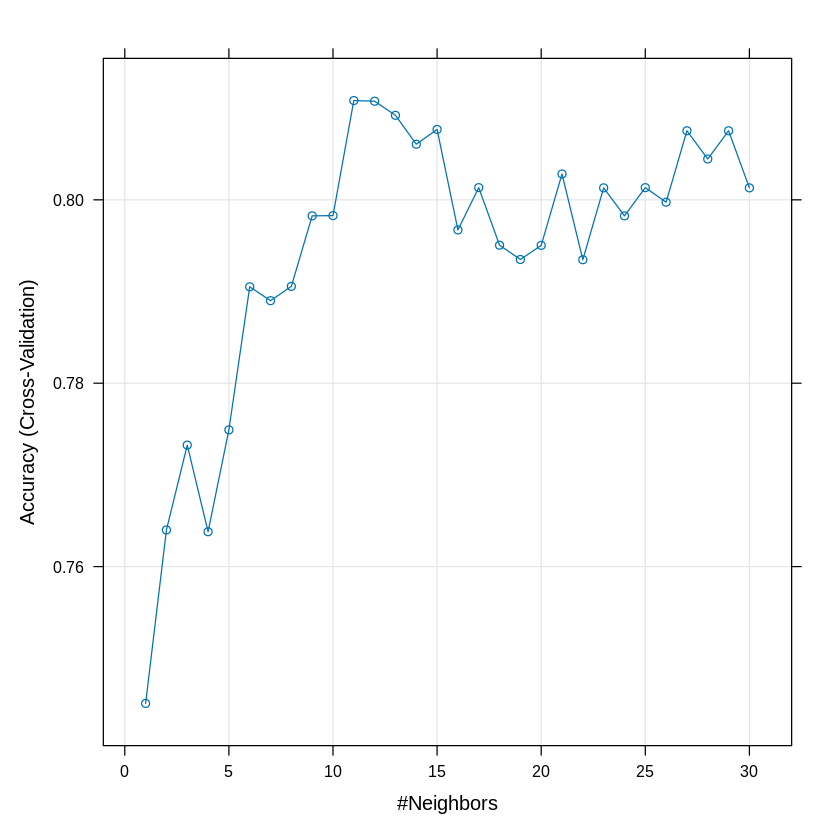

In [81]:
modeloknn1
plot(modeloknn1)

De los resultados obtenidos es visible que el modelo más parsimonioso con buenos resultados usa k=6, y el modelo seleccionado por el método es de k=11. Vamos a hacer predicciones basados en la sugerencia del modelo.

In [82]:
predmod1<-predict(modeloknn1,cartera.test,type="prob")
colnames(predmod1)<-c("no","si")
pronknn1<-ifelse(predmod1$si > 0.5,1,0)
confknn1<-confusionMatrix(as.factor(pronknn1),
                          cartera.test$retrasos, positive = "1")
confknn1$table
as.data.frame(confknn1$byClass)


          Reference
Prediction   0   1
         0 158  37
         1   3  15

,confknn1$byClass
,<dbl>
Sensitivity,0.28846154
Specificity,0.98136646
Pos Pred Value,0.83333333
Neg Pred Value,0.81025641
Precision,0.83333333
Recall,0.28846154
F1,0.42857143
Prevalence,0.24413146
Detection Rate,0.07042254


Ahora veamos la curva COR

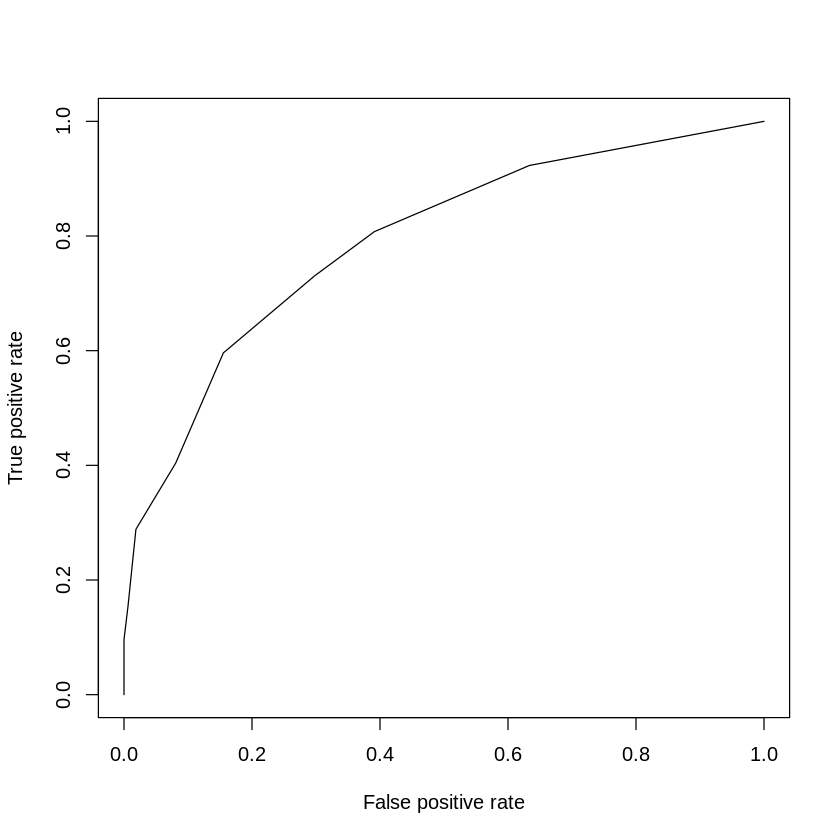

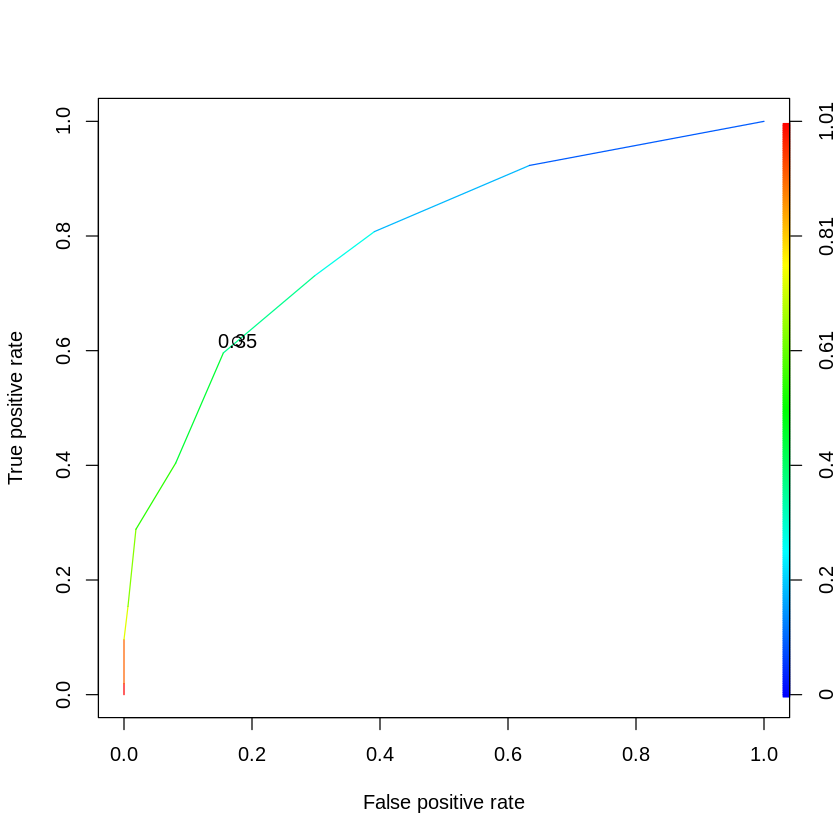

In [83]:
library(ROCR)
#crear objeto de predicciones
pr<-prediction(predmod1$si,cartera.test$retrasos)
#creacion del objeto de la curva
curvaROC<-performance(pr,measure="tpr",x.measure="fpr")
#grafico de la curva
plot(curvaROC)
plot(curvaROC, colorize=TRUE, colorkey=TRUE, print.cutoffs.at=c(0.35))


In [84]:
#calcular el AUC
auc<-performance(pr,measure = "auc")
auc <- auc@y.values[[1]]
#ver el AUC
auc


[1] 0.790731

Podemos ver que los resultados son competitivos con la regresión logística (hecha en un notebook previo) donde sin balancear, el AUC obtenido era apenas 1.2 puntos porcentuales superior

Sin embargo nótese que estamos usando como medida de precisión “accuracy”. Dado el ligero desbalance de la base de datos, y que nos interesa particularmente predecir los retrasos, quizás sea mejor utilizar otra métrica y balancear.



In [85]:
if (!require('ROSE')) install.packages('ROSE')
library(ROSE)

In [86]:
cartera.train.over<-ovun.sample(retrasos~.,data=cartera.train,method="over",p=0.49,seed=398)$data
table(cartera.train.over$retrasos)


  0   1 
498 501 

Debemos hacer algunos ajustes para que la librería caret me permita usar el AUC

k-Nearest Neighbors 

999 samples
  8 predictor
  2 classes: 'X0', 'X1' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 798, 799, 799, 800, 800 
Resampling results across tuning parameters:

  k   AUC        Precision  Recall     F        
   1  0.1230747  0.9669657  0.8313939  0.8939614
   2  0.2163633  0.9205774  0.7409899  0.8207659
   3  0.2922256  0.9142467  0.6787879  0.7787822
   4  0.3369101  0.8837454  0.6666869  0.7595291
   5  0.3697384  0.8705630  0.6626061  0.7523504
   6  0.4044914  0.8690836  0.6607071  0.7500729
   7  0.4336759  0.8704288  0.6547273  0.7465161
   8  0.4699723  0.8617895  0.6426263  0.7356977
   9  0.5077479  0.8515001  0.6566869  0.7411349
  10  0.5409345  0.8494510  0.6688081  0.7476056
  11  0.5672988  0.8385246  0.6787677  0.7493349
  12  0.5847426  0.8227496  0.6747677  0.7400958
  13  0.5978255  0.8199070  0.6807879  0.7424943
  14  0.6028882  0.8097350  0.6727677  0.7338782
  15  0.6206314  0.8095105  0.6727475  

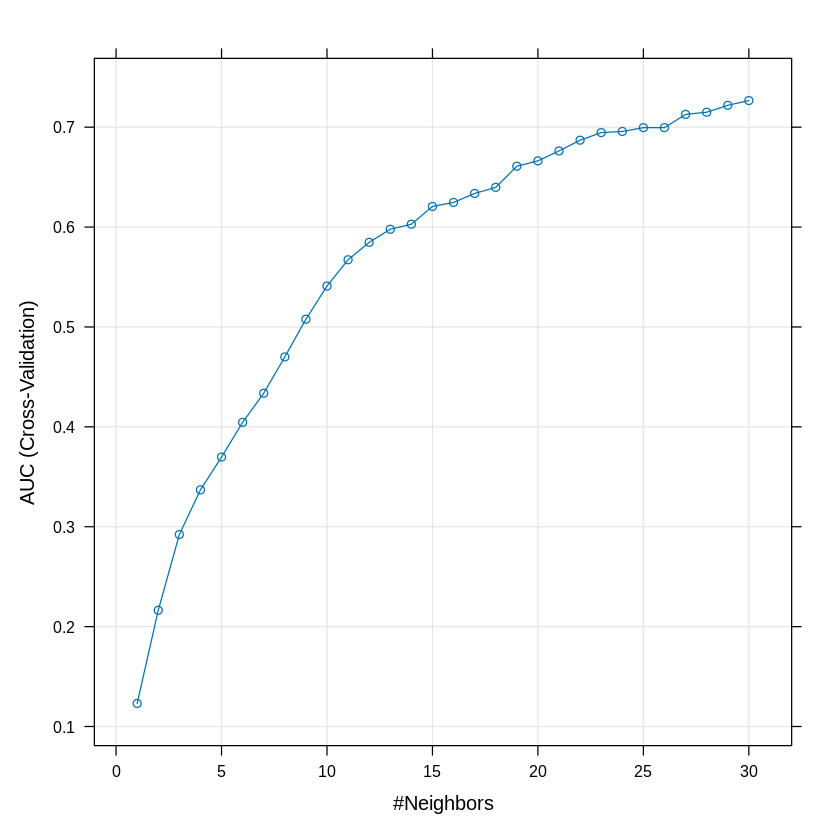

In [87]:
##para hacerlo con AUC
levels(cartera.train.over$retrasos) <- make.names(levels(factor(cartera.train.over$retrasos)))

# creo parámetros de validación cruzada
cross<-trainControl(method="cv",number=5,
                    classProbs = TRUE,
                    summaryFunction =prSummary)
modeloknn2<-train(retrasos~.,method="knn",
                  tuneGrid=expand.grid(k=1:30),
                  trControl=cross,
                  metric="AUC",
                  data=cartera.train.over)
modeloknn2
plot(modeloknn2)



El modelo me pide un número alto de vecinos. Veamos su desempeño en prueba

In [88]:
# el modelo sintonizado
predmod2<-predict(modeloknn2,cartera.test,type="prob")
pronknn2<-ifelse(predmod2$X1 > 0.5,1,0)
confknn2<-confusionMatrix(as.factor(pronknn2),
                          cartera.test$retrasos, positive = "1")
confknn2$table
as.data.frame(confknn2$byClass)


          Reference
Prediction   0   1
         0 117  12
         1  44  40

,confknn2$byClass
,<dbl>
Sensitivity,0.7692308
Specificity,0.7267081
Pos Pred Value,0.4761905
Neg Pred Value,0.9069767
Precision,0.4761905
Recall,0.7692308
F1,0.5882353
Prevalence,0.2441315
Detection Rate,0.1877934


El modelo mejora en F score. Veamos su métrica AUC

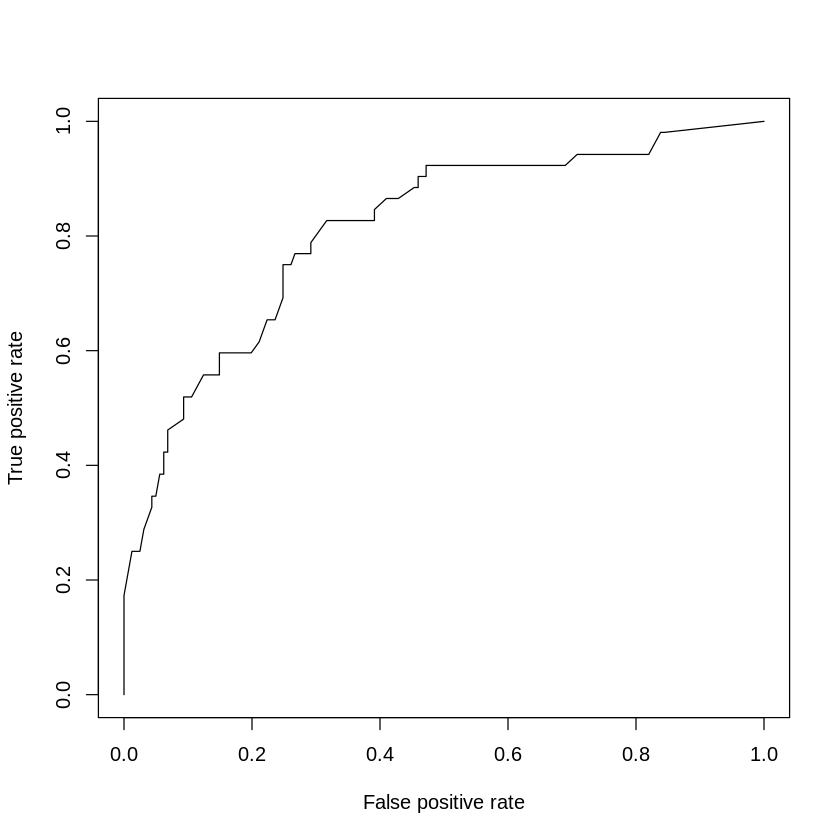

[1] 0.790731

[1] 0.8107979

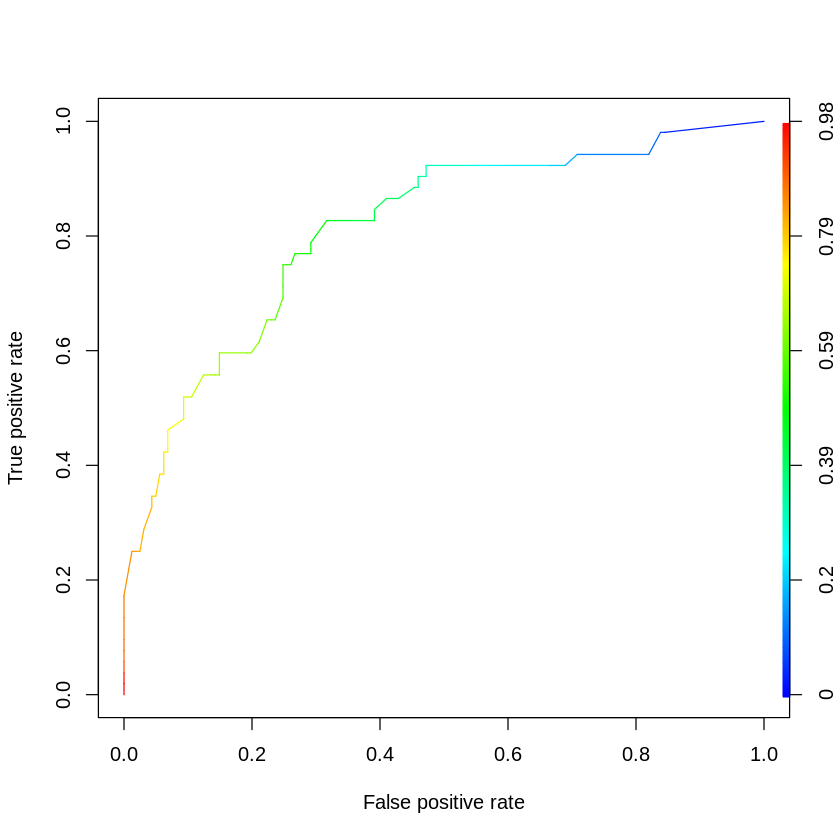

In [71]:
#crear objeto de predicciones
pr2<-prediction(predmod2$X1,cartera.test$retrasos)
#creacion del objeto de la curva
curvaROC2<-performance(pr2,measure="tpr",x.measure="fpr")

##
#grafico de la curva
plot(curvaROC2)
plot(curvaROC2, colorize=TRUE, colorkey=TRUE)

#calcular el AUC
auc2<-performance(pr2,measure = "auc")
auc2 <- auc2@y.values[[1]]
#ver el AUC
auc
auc2

Los resultados son inferiores a los de una regresión logística con selección de variables basada en pasos sucesivos y balanceo, pero no por mucho.

Aunque KNN también puede usarse para predicciones de variables escalares, KNN es con frecuencia un modelo que puede utilizarse como modelo de base o ingenuo para una clasificación, particularmente con variables predictoras escalares.
También podemos comparar gráficamente los dos modelos que hemos hecho con KNN

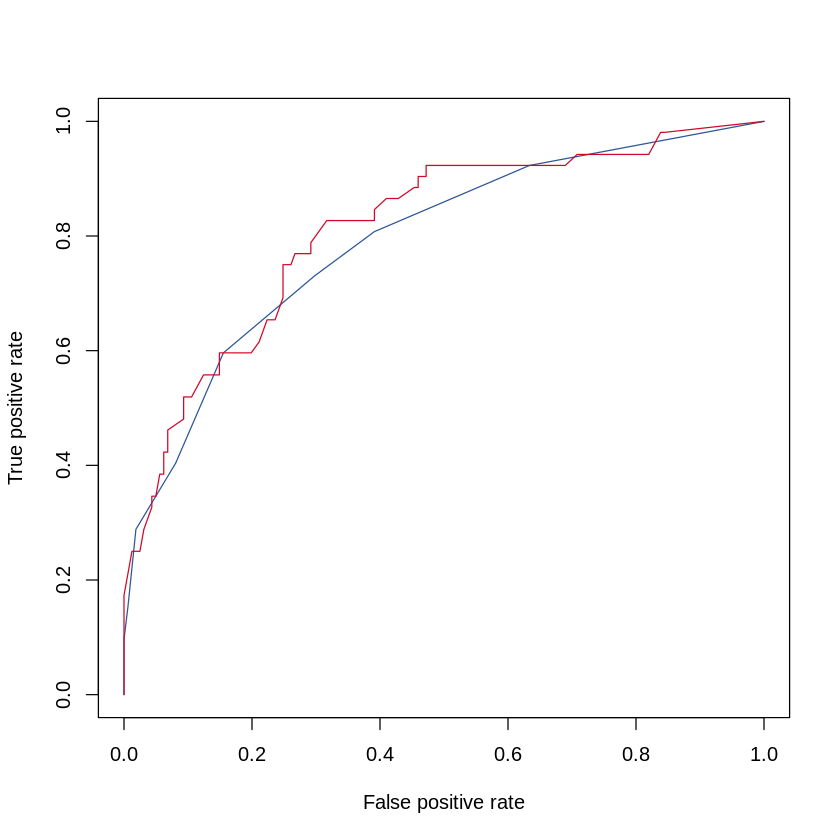

In [94]:
plot(curvaROC, col="#2c5697")
plot(curvaROC2, col="#d20728", add=TRUE)


Obsérvese que nuestro modelo balanceado obtuvo el máximo k posible. ¿aumentar el k mejorará aun más los resultados? Miremos

In [107]:
modeloknn3<-train(retrasos~.,method="knn",
                  tuneGrid=expand.grid(k=31:70),
                  trControl=cross,
                  metric="AUC",
                  data=cartera.train.over)

modeloknn3$bestTune

,k
,<int>
39,69


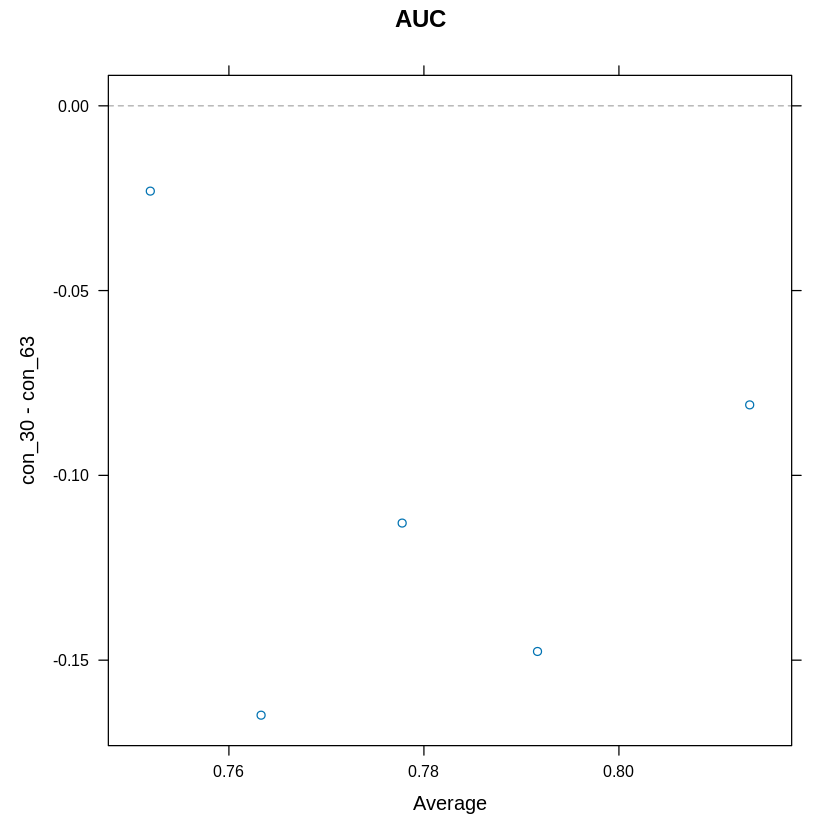

In [100]:
resamps <- resamples(list(con_30 = modeloknn2, con_63 = modeloknn3))
xyplot(resamps, what = "BlandAltman")

Parece que en cada submuestra el modelo de 65 se desempeñó mejor que el de 30. Es posible hacer una diferencia t de student de muestras pareadas dado que los remuestreos son iguales. El resultado en entrenamiento es que hay un posible aumento en el AUC

In [97]:
diffs <- diff(resamps)
summary(diffs)


Call:
summary.diff.resamples(object = diffs)

p-value adjustment: bonferroni 
Upper diagonal: estimates of the difference
Lower diagonal: p-value for H0: difference = 0

AUC 
       con_30   con_65 
con_30          -0.0987
con_65 0.003145        

F 
       con_30 con_65 
con_30        -0.0147
con_65 0.4777        

Precision 
       con_30 con_65  
con_30        0.005761
con_65 0.8749         

Recall 
       con_30 con_65  
con_30        -0.03426
con_65 0.3116         


Probémoslo en la base de prueba

In [106]:
predmod3<-predict(modeloknn3,cartera.test,type="prob")
pr3<-prediction(predmod3$X1,cartera.test$retrasos)
curvaROC3<-performance(pr3,measure="tpr",x.measure="fpr")

#calcular el AUC
auc3<-performance(pr3,measure = "auc")
auc3 <- auc3@y.values[[1]]
#ver el AUC
auc2
auc3

[1] 0.8107979

[1] 0.7874462

En la base de prueba, el aumento de k muestra de hecho un decrecimiento, debido a un posible underfitting. Sería importante analizar si bajar el k (inclusive por debajo de 30) mantiene o mejora el desempeño.

##Conclusión
En este libro de notas revisamos la técnica de KNN para clasificación, que puede usarse como línea de base ingenua y que es sorprendentemente bueno a pesar de su sencillez. Un modelo más sofisticado debe demostrar su utilidad frente a modelos ingenuos para justificar el esfuerzo de su realización. lastimosamente, esta técnica básica no es muy escalable a grandes volúmenes de datos.